# QAOA — Minimum Partial Dominating Set
### Actividad Grupal: Minimizar costos publicitarios

**Objetivo:** Dado un grafo de red social, encontrar el conjunto mínimo de nodos (personas) que cubra al menos un porcentaje **θ** del grafo, utilizando el algoritmo QAOA con **p = 3 capas**.

**Diseño de software:**
- Interfaz abstracta `QAOASolver`
- Implementación `QiskitSolver`
- Implementación `PennyLaneSolver`
- Factoría `QAOASolverFactory`

**Parámetros configurables:**
| Parámetro | Descripción |
|-----------|-------------|
| `graph`   | Grafo NetworkX (genérico) |
| `theta`   | Cobertura mínima requerida (0.0 – 1.0) |
| `p`       | Número de capas QAOA |
| `A`       | Peso del término de costo |
| `B`       | Peso de la penalización por cobertura |
| `provider`| `'qiskit'` o `'pennylane'` |

## 1. Instalación de dependencias

> Ejecutar solo si no están instaladas.

In [46]:
# !pip install qiskit qiskit-aer qiskit-algorithms
# !pip install pennylane
# !pip install networkx matplotlib scipy numpy

## 2. Imports y configuración global

In [47]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from abc import ABC, abstractmethod
from itertools import product
from scipy.optimize import minimize
import time
import warnings
warnings.filterwarnings('ignore')

# ── Qiskit ──────────────────────────────────────────────────────────
from qiskit import QuantumCircuit
from qiskit.circuit import Parameter, ParameterVector
from qiskit_aer import AerSimulator
from qiskit.quantum_info import SparsePauliOp
from qiskit.primitives import StatevectorSampler

# ── PennyLane ────────────────────────────────────────────────────────
import pennylane as qml
from pennylane import numpy as pnp

print('✅ Imports correctos')
print(f'   Qiskit Aer  disponible')
print(f'   PennyLane   v{qml.__version__}')

✅ Imports correctos
   Qiskit Aer  disponible
   PennyLane   v0.45.0


## 3. Definición del grafo

Construimos el grafo de la red social del enunciado con NetworkX.
El diseño es **genérico**: puedes sustituir `G` por cualquier grafo de NetworkX.

Nodos (6): ['Mario', 'Enrique', 'Sarah', 'Ana', 'Raúl', 'Saúl']
Aristas (6): [('Mario', 'Sarah'), ('Mario', 'Raúl'), ('Mario', 'Ana'), ('Enrique', 'Sarah'), ('Enrique', 'Raúl'), ('Ana', 'Saúl')]


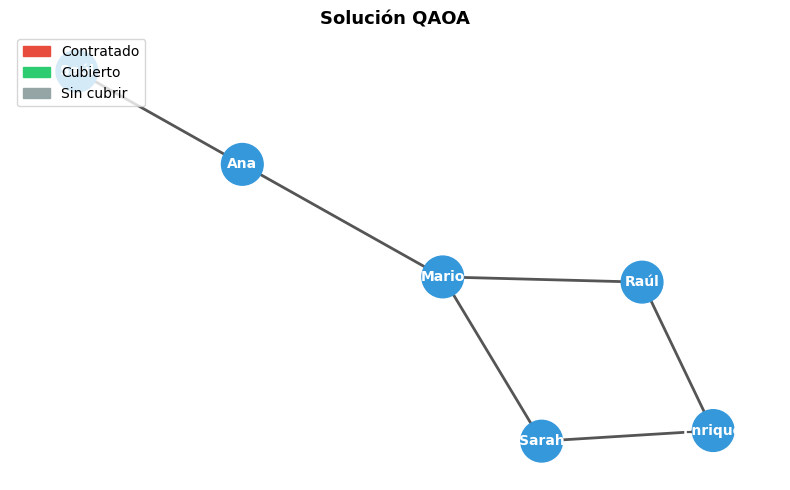

In [48]:
def build_social_graph() -> nx.Graph:
    """
    Construye el grafo de la red social del enunciado.
    
    Personas: Mario, Enrique, Sarah, Ana, Raúl, Saúl
    Relaciones (no dirigidas):
        Mario   -- Sarah, Raúl, Ana
        Enrique -- Sarah, Raúl
        Saúl    -- Ana
    """
    G = nx.Graph()
    personas = ['Mario', 'Enrique', 'Sarah', 'Ana', 'Raúl', 'Saúl']
    G.add_nodes_from(personas)
    G.add_edges_from([
        ('Mario',   'Sarah'),
        ('Mario',   'Raúl'),
        ('Mario',   'Ana'),
        ('Enrique', 'Sarah'),
        ('Enrique', 'Raúl'),
        ('Saúl',    'Ana'),
    ])
    return G


def visualize_graph(G: nx.Graph, solution: list = None, theta: float = None):
    """
    Visualiza el grafo.
    - Nodos rojos   : persona contratada (en el dominating set)
    - Nodos verdes  : persona cubierta por un vecino contratado
    - Nodos grises  : persona no cubierta
    """
    nodes = list(G.nodes())
    pos = nx.spring_layout(G, seed=42)

    if solution is not None:
        hired   = {nodes[i] for i, v in enumerate(solution) if v == 1}
        covered = set(hired)
        for h in hired:
            covered.update(G.neighbors(h))
        colors = []
        for n in nodes:
            if n in hired:
                colors.append('#e74c3c')   # contratado
            elif n in covered:
                colors.append('#2ecc71')   # cubierto
            else:
                colors.append('#95a5a6')   # sin cubrir
    else:
        colors = ['#3498db'] * len(nodes)

    fig, ax = plt.subplots(figsize=(8, 5))
    nx.draw_networkx(G, pos=pos, node_color=colors, node_size=900,
                     font_size=10, font_color='white', font_weight='bold',
                     edge_color='#555', width=2, ax=ax)
    legend = [
        mpatches.Patch(color='#e74c3c', label='Contratado'),
        mpatches.Patch(color='#2ecc71', label='Cubierto'),
        mpatches.Patch(color='#95a5a6', label='Sin cubrir'),
    ]
    title = f'Solución QAOA'
    if theta is not None:
        title += f'  (θ = {theta:.0%})'
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.legend(handles=legend, loc='upper left')
    ax.axis('off')
    plt.tight_layout()
    plt.show()


# ── Construir y mostrar el grafo inicial ──────────────────────────────
G = build_social_graph()
print(f'Nodos ({G.number_of_nodes()}): {list(G.nodes())}')
print(f'Aristas ({G.number_of_edges()}): {list(G.edges())}')
visualize_graph(G)

## 4. Hamiltoniano del problema

### Formulación QUBO

Cada nodo $i$ tiene un qubit $x_i \in \{0, 1\}$, donde $x_i = 1$ significa "persona contratada".

**Cobertura de un nodo $i$:**
$$c_i = x_i + \sum_{j \in N(i)} x_j$$
El nodo $i$ está cubierto si $c_i \geq 1$.

**Hamiltoniano de costo** (minimizar número de contratados):
$$H_{\text{costo}} = \sum_i x_i$$

**Hamiltoniano de penalización** (penalizar soluciones con cobertura < θ·N):
$$H_{\text{pen}} = \sum_i \max(0,\, 1 - c_i)^2$$

**Hamiltoniano total:**
$$H = A \cdot H_{\text{costo}} + B \cdot H_{\text{pen}}$$

En la práctica QAOA usamos la representación de Pauli $Z$ con $x_i = (1 - Z_i)/2$.

In [49]:
def compute_cost(bitstring: list, G: nx.Graph, A: float, B: float, theta: float) -> float:
    """
    Calcula el costo de una solución clásica (bitstring).

    Parámetros
    ----------
    bitstring : lista de 0/1, longitud = número de nodos
    G         : grafo NetworkX
    A         : peso del término de costo (minimizar contratados)
    B         : peso de la penalización (cobertura < theta)
    theta     : fracción mínima de cobertura requerida [0, 1]

    Retorna
    -------
    float : valor del Hamiltoniano para ese bitstring
    """
    nodes = list(G.nodes())
    n = len(nodes)
    x = {nodes[i]: bitstring[i] for i in range(n)}

    # Término de costo: número de contratados
    cost = A * sum(x.values())

    # Término de penalización: nodos no cubiertos
    uncovered = 0
    for node in nodes:
        coverage = x[node] + sum(x[nb] for nb in G.neighbors(node))
        if coverage == 0:
            uncovered += 1

    # Penalizamos si la cobertura total < theta * N
    covered_count = n - uncovered
    required = int(np.ceil(theta * n))
    if covered_count < required:
        penalty = B * (required - covered_count) ** 2
    else:
        penalty = 0

    return cost + penalty


def coverage_fraction(bitstring: list, G: nx.Graph) -> float:
    """Calcula la fracción del grafo cubierta por el dominating set."""
    nodes = list(G.nodes())
    x = {nodes[i]: bitstring[i] for i in range(len(nodes))}
    covered = set()
    for node in nodes:
        if x[node] == 1:
            covered.add(node)
            covered.update(G.neighbors(node))
    return len(covered) / len(nodes)


# ── Test rápido con solución conocida ────────────────────────────────
nodes = list(G.nodes())  # ['Mario','Enrique','Sarah','Ana','Raúl','Saúl']
test_solution = [1, 1, 0, 0, 0, 1]  # Mario, Enrique, Saúl contratados
cov = coverage_fraction(test_solution, G)
cost_val = compute_cost(test_solution, G, A=1.0, B=3.0, theta=1.0)

print('Solución de prueba:', dict(zip(nodes, test_solution)))
print(f'Cobertura: {cov:.1%}')
print(f'Costo H:   {cost_val:.2f}')

Solución de prueba: {'Mario': 1, 'Enrique': 1, 'Sarah': 0, 'Ana': 0, 'Raúl': 0, 'Saúl': 1}
Cobertura: 100.0%
Costo H:   3.00


## 5. Interfaz abstracta `QAOASolver`

In [50]:
class QAOASolver(ABC):
    """
    Interfaz abstracta para solvers QAOA.

    Todos los solvers reciben la misma configuración y devuelven
    el mismo formato de resultado, lo que permite comparaciones justas.
    """

    def __init__(self, G: nx.Graph, p: int = 3,
                 theta: float = 1.0, A: float = 1.0, B: float = 3.0,
                 shots: int = 1024):
        """
        Parámetros
        ----------
        G     : grafo NetworkX
        p     : número de capas QAOA
        theta : cobertura mínima requerida (0.0 – 1.0)
        A     : peso del término de costo
        B     : peso de la penalización
        shots : número de mediciones por circuito
        """
        self.G     = G
        self.p     = p
        self.theta = theta
        self.A     = A
        self.B     = B
        self.shots = shots
        self.nodes = list(G.nodes())
        self.n     = len(self.nodes)

    @abstractmethod
    def build_circuit(self, gamma: list, beta: list):
        """Construye el circuito QAOA para unos parámetros γ, β dados."""
        pass

    @abstractmethod
    def expectation(self, params: np.ndarray) -> float:
        """Calcula el valor esperado del Hamiltoniano para unos parámetros."""
        pass

    @abstractmethod
    def sample(self, gamma: list, beta: list) -> dict:
        """Ejecuta el circuito y devuelve el histograma de mediciones."""
        pass

    def solve(self) -> dict:
        """
        Ejecuta el flujo completo QAOA:
        1. Búsqueda de parámetros óptimos (γ*, β*)
        2. Muestreo del circuito con parámetros óptimos
        3. Selección de la mejor solución
        4. Cálculo de métricas

        Retorna
        -------
        dict con claves:
            solution      : lista de 0/1
            hired         : nombres de personas contratadas
            coverage      : fracción de cobertura obtenida
            n_hired       : número de personas contratadas
            optimal_gamma : lista de γ óptimos
            optimal_beta  : lista de β óptimos
            counts        : histograma de mediciones
            exec_time     : tiempo de ejecución (segundos)
            provider      : nombre del proveedor
        """
        t0 = time.time()

        # ── Inicialización de parámetros ──────────────────────────────
        # Búsqueda en grid gruesa primero, luego refinamiento con COBYLA
        best_params, best_val = self._grid_search()
        result = minimize(
            self.expectation,
            best_params,
            method='COBYLA',
            options={'maxiter': 500, 'rhobeg': 0.3}
        )
        optimal_params = result.x
        gamma_opt = list(optimal_params[:self.p])
        beta_opt  = list(optimal_params[self.p:])

        # ── Muestreo con parámetros óptimos ───────────────────────────
        counts = self.sample(gamma_opt, beta_opt)

        # ── Selección de la mejor solución válida ─────────────────────
        best_bitstring, best_cost = self._best_from_counts(counts)

        exec_time = time.time() - t0

        hired    = [self.nodes[i] for i, v in enumerate(best_bitstring) if v == 1]
        coverage = coverage_fraction(best_bitstring, self.G)

        return {
            'solution':      best_bitstring,
            'hired':         hired,
            'coverage':      coverage,
            'n_hired':       sum(best_bitstring),
            'optimal_gamma': gamma_opt,
            'optimal_beta':  beta_opt,
            'counts':        counts,
            'exec_time':     exec_time,
            'provider':      self.provider_name,
        }

    def _grid_search(self, steps: int = 5) -> tuple:
        """Búsqueda en grid para inicializar el optimizador clásico."""
        gamma_range = np.linspace(0, np.pi,     steps)
        beta_range  = np.linspace(0, np.pi / 2, steps)

        best_val    = np.inf
        best_params = np.zeros(2 * self.p)

        # Para p=3, hacemos grid de la primera capa y repetimos
        for g in gamma_range:
            for b in beta_range:
                params = np.array([g] * self.p + [b] * self.p)
                val = self.expectation(params)
                if val < best_val:
                    best_val    = val
                    best_params = params
        return best_params, best_val

    def _best_from_counts(self, counts: dict) -> tuple:
        """Selecciona la solución con menor costo entre las medidas."""
        best_bitstring = None
        best_cost      = np.inf
        for bitstring_str, freq in counts.items():
            bits = [int(b) for b in bitstring_str]
            cost = compute_cost(bits, self.G, self.A, self.B, self.theta)
            if cost < best_cost:
                best_cost      = cost
                best_bitstring = bits
        return best_bitstring, best_cost

    @property
    @abstractmethod
    def provider_name(self) -> str:
        pass


print('✅ Interfaz QAOASolver definida')

✅ Interfaz QAOASolver definida


## 6. Implementación Qiskit — `QiskitSolver`

Construye el circuito QAOA manualmente usando `QuantumCircuit` de Qiskit:
- **Estado inicial:** superposición uniforme con puertas Hadamard
- **Puerta U(C):** capa de costo con puertas $R_{ZZ}$ y $R_Z$
- **Puerta U(B):** capa de mixing con puertas $R_X$
- **p = 3 capas** alternando U(C) y U(B)

In [51]:
class QiskitSolver(QAOASolver):
    """
    Implementación QAOA con Qiskit + AerSimulator.

    Circuito:
        |s⟩ = H^n |0⟩
        |γ,β⟩ = [U(B,βₚ) · U(C,γₚ)]^p |s⟩

    U(C, γ): codifica H_costo + H_pen como rotaciones ZZ y Z
    U(B, β): mixer estándar Rx(2β) en cada qubit
    """

    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.simulator = AerSimulator()

    @property
    def provider_name(self) -> str:
        return 'Qiskit'

    def _cost_unitary(self, qc: QuantumCircuit, gamma: float):
        """
        Puerta U(C, γ): aplica la evolución e^{-iγH_C}.

        En representación de Pauli Z (x_i = (1-Z_i)/2):
        - Término de costo:      A/2 · Σ Z_i  → Rz(A·γ) por qubit
        - Término de penalización se aproxima como interacciones ZZ:
          si (i,j) son vecinos → Rzz(B·γ)
        """
        # Rotaciones Z individuales (término de costo)
        for i in range(self.n):
            qc.rz(2 * self.A * gamma, i)

        # Rotaciones ZZ entre nodos vecinos (término de penalización)
        node_idx = {node: i for i, node in enumerate(self.nodes)}
        for u, v in self.G.edges():
            i, j = node_idx[u], node_idx[v]
            # Rzz(θ) = CNOT · Rz(θ) · CNOT
            qc.cx(i, j)
            qc.rz(2 * self.B * gamma, j)
            qc.cx(i, j)

    def _mixer_unitary(self, qc: QuantumCircuit, beta: float):
        """Puerta U(B, β): mixer estándar Rx(2β) en cada qubit."""
        for i in range(self.n):
            qc.rx(2 * beta, i)

    def build_circuit(self, gamma: list, beta: list) -> QuantumCircuit:
        """
        Construye el circuito QAOA completo.

        |ψ(γ,β)⟩ = U(B,β_p)·U(C,γ_p)·...·U(B,β_1)·U(C,γ_1)|s⟩
        """
        qc = QuantumCircuit(self.n, self.n)

        # Estado inicial: superposición uniforme
        qc.h(range(self.n))

        # p capas alternando U(C) y U(B)
        for layer in range(self.p):
            self._cost_unitary(qc, gamma[layer])
            self._mixer_unitary(qc, beta[layer])

        # Medición
        qc.measure(range(self.n), range(self.n))
        return qc

    def sample(self, gamma: list, beta: list) -> dict:
        """Ejecuta el circuito y devuelve el histograma de mediciones."""
        qc = self.build_circuit(gamma, beta)
        job    = self.simulator.run(qc, shots=self.shots)
        result = job.result()
        raw_counts = result.get_counts()
        # Normalizar: Qiskit devuelve bitstring en orden inverso
        counts = {k[::-1]: v for k, v in raw_counts.items()}
        return counts

    def expectation(self, params: np.ndarray) -> float:
        """
        Calcula <ψ(γ,β)|H|ψ(γ,β)> como media del costo
        sobre todas las mediciones (estimación Monte Carlo).
        """
        gamma = params[:self.p]
        beta  = params[self.p:]
        counts = self.sample(gamma, beta)
        total_shots = sum(counts.values())
        exp_val = sum(
            compute_cost([int(b) for b in bits], self.G,
                         self.A, self.B, self.theta) * freq
            for bits, freq in counts.items()
        ) / total_shots
        return exp_val


print('✅ QiskitSolver definido')

# ── Mostrar estructura del circuito ──────────────────────────────────
solver_qk = QiskitSolver(G, p=3, theta=1.0, A=1.0, B=3.0, shots=1024)
qc_ejemplo = solver_qk.build_circuit([0.5, 0.5, 0.5], [0.3, 0.3, 0.3])
print('\nCircuito QAOA (p=3):')
print(qc_ejemplo.draw(output='text', fold=120))

✅ QiskitSolver definido

Circuito QAOA (p=3):
     ┌───┐┌───────┐                                                                                       ┌─────────┐»
q_0: ┤ H ├┤ Rz(1) ├──■─────────────■────■──────────────────────■─────────■─────────────────────────────■──┤ Rx(0.6) ├»
     ├───┤├───────┤  │             │    │                      │         │                             │  └─────────┘»
q_1: ┤ H ├┤ Rz(1) ├──┼─────────────┼────┼──────■───────────────┼────■────┼────■────────────────────────┼───────■─────»
     ├───┤├───────┤┌─┴─┐┌───────┐┌─┴─┐  │    ┌─┴─┐  ┌───────┐  │  ┌─┴─┐  │    │  ┌─────────┐┌───────┐  │       │     »
q_2: ┤ H ├┤ Rz(1) ├┤ X ├┤ Rz(3) ├┤ X ├──┼────┤ X ├──┤ Rz(3) ├──┼──┤ X ├──┼────┼──┤ Rx(0.6) ├┤ Rz(1) ├──┼───────┼─────»
     ├───┤├───────┤└───┘└───────┘└───┘  │    └───┘  └───────┘  │  └───┘┌─┴─┐  │  └┬───────┬┘└───────┘┌─┴─┐     │     »
q_3: ┤ H ├┤ Rz(1) ├─────────────────────┼──────────────────────┼───────┤ X ├──┼───┤ Rz(3) ├──────────┤ X ├─────┼─────»
  

## 7. Implementación PennyLane — `PennyLaneSolver`

Misma lógica QAOA, implementada con PennyLane:
- Usa `qml.device('default.qubit')` **sin shots** para el cálculo analítico del valor esperado
- Las puertas son `qml.RZ`, `qml.IsingZZ`, `qml.RX`
- El Hamiltoniano de costo se expresa como `qml.Hamiltonian` (combinación lineal de operadores de Pauli)
- Los gradientes se calculan con **parameter-shift rule** (`diff_method='parameter-shift'`): evalúa el circuito en θ ± π/2 para cada parámetro y calcula la derivada exacta
- El optimizador clásico es **L-BFGS-B** (gradiente de segundo orden), que aprovecha los gradientes exactos

In [52]:
class PennyLaneSolver(QAOASolver):
    """
    Implementación QAOA con PennyLane + parameter-shift rule.

    Arquitectura de dos devices:
    - dev_analytic : default.qubit sin shots -> calcula <H_cost> de forma
      exacta y diferenciable con diff_method='parameter-shift'.
    - dev_shots    : default.qubit con shots -> muestrea la distribucion
      final para extraer la mejor solucion clasica.

    Flujo de optimizacion:
        grid_search  ->  L-BFGS-B con gradientes parameter-shift  ->  sample
    """

    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        # Device analitico (sin shots) para gradientes exactos
        self.dev_analytic = qml.device('default.qubit', wires=self.n)
        # Device con shots para muestreo final
        self.dev_shots    = qml.device('default.qubit', wires=self.n, shots=self.shots)
        self.node_idx = {node: i for i, node in enumerate(self.nodes)}
        self._build_cost_hamiltonian()

    @property
    def provider_name(self) -> str:
        return 'PennyLane'

    def _build_cost_hamiltonian(self):
        """
        Expresa el Hamiltoniano de costo como observable de PennyLane:

            H = A * sum_i Z_i  +  B * sum_{(i,j) in E} Z_i Z_j

        Corresponde exactamente a la codificacion del circuito:
        - Rz(2*A*gamma) en cada qubit       <->  A * Z_i
        - IsingZZ(2*B*gamma) en cada arista  <->  B * Z_i Z_j
        """
        coeffs, ops = [], []
        for i in range(self.n):
            coeffs.append(self.A)
            ops.append(qml.PauliZ(i))
        for u, v in self.G.edges():
            i, j = self.node_idx[u], self.node_idx[v]
            coeffs.append(self.B)
            ops.append(qml.PauliZ(i) @ qml.PauliZ(j))
        self.H_cost = qml.Hamiltonian(coeffs, ops)

    def _qaoa_circuit(self, gamma, beta):
        """Circuito QAOA sin medicion (compartido entre QNodes)."""
        for i in range(self.n):
            qml.Hadamard(wires=i)
        for layer in range(self.p):
            # U(C, gamma): capa de costo
            for i in range(self.n):
                qml.RZ(2 * self.A * gamma[layer], wires=i)
            for u, v in self.G.edges():
                i, j = self.node_idx[u], self.node_idx[v]
                qml.IsingZZ(2 * self.B * gamma[layer], wires=[i, j])
            # U(B, beta): capa de mixing
            for i in range(self.n):
                qml.RX(2 * beta[layer], wires=i)

    def _make_expval_qnode(self):
        """
        QNode diferenciable: devuelve <H_cost> con parameter-shift rule.

        La parameter-shift rule calcula el gradiente exacto:
            df/dtheta = [ f(theta + pi/2) - f(theta - pi/2) ] / 2

        sin aproximaciones de diferencias finitas.
        """
        H = self.H_cost
        p = self.p

        @qml.qnode(self.dev_analytic, diff_method='parameter-shift')
        def circuit(params):
            gamma = params[:p]
            beta  = params[p:]
            self._qaoa_circuit(gamma, beta)
            return qml.expval(H)

        return circuit

    def build_circuit(self, gamma: list, beta: list):
        """QNode con shots para muestreo de bitstrings."""
        @qml.qnode(self.dev_shots)
        def circuit():
            self._qaoa_circuit(gamma, beta)
            return qml.sample(wires=range(self.n))
        return circuit

    def sample(self, gamma: list, beta: list) -> dict:
        """Muestrea la distribucion con parametros fijos y devuelve histograma."""
        samples = self.build_circuit(gamma, beta)()
        counts = {}
        for s in samples:
            key = ''.join(map(str, s))
            counts[key] = counts.get(key, 0) + 1
        return counts

    def expectation(self, params: np.ndarray) -> float:
        """
        Calcula <H_cost> de forma analitica (sin ruido de muestreo).
        Usado por _grid_search para inicializar el optimizador.
        """
        circuit = self._make_expval_qnode()
        return float(circuit(pnp.array(params, requires_grad=False)))

    def solve(self) -> dict:
        """
        Flujo QAOA con parameter-shift rule:

        1. Grid search  : inicializacion en el minimo aproximado
        2. L-BFGS-B     : optimizacion de segundo orden con gradientes
                          exactos calculados por parameter-shift
        3. Muestreo     : extraccion de la mejor solucion clasica
        """
        t0 = time.time()

        # Inicializacion
        best_params, _ = self._grid_search()

        # Optimizacion con gradientes exactos
        circuit = self._make_expval_qnode()

        def cost_and_grad(params):
            p_arr = pnp.array(params, requires_grad=True)
            val   = float(circuit(p_arr))
            grad  = np.array(qml.grad(circuit)(p_arr))
            return val, grad

        result = minimize(
            cost_and_grad,
            best_params,
            method='L-BFGS-B',
            jac=True,
            options={'maxiter': 500, 'ftol': 1e-9}
        )

        optimal_params = result.x
        gamma_opt = list(optimal_params[:self.p])
        beta_opt  = list(optimal_params[self.p:])

        # Muestreo con parametros optimos
        counts = self.sample(gamma_opt, beta_opt)
        best_bitstring, _ = self._best_from_counts(counts)

        exec_time = time.time() - t0
        hired    = [self.nodes[i] for i, v in enumerate(best_bitstring) if v == 1]
        coverage = coverage_fraction(best_bitstring, self.G)

        return {
            'solution':      best_bitstring,
            'hired':         hired,
            'coverage':      coverage,
            'n_hired':       sum(best_bitstring),
            'optimal_gamma': gamma_opt,
            'optimal_beta':  beta_opt,
            'counts':        counts,
            'exec_time':     exec_time,
            'provider':      self.provider_name,
        }


print('PennyLaneSolver definido (parameter-shift rule + L-BFGS-B)')

PennyLaneSolver definido (parameter-shift rule + L-BFGS-B)


## 8. Factoría `QAOASolverFactory`

In [53]:
class QAOASolverFactory:
    """
    Factoría que instancia el solver correcto según el parámetro 'provider'.

    Uso:
        solver = QAOASolverFactory.create(config)
        result = solver.solve()
    """

    _registry = {
        'qiskit':    QiskitSolver,
        'pennylane': PennyLaneSolver,
    }

    @classmethod
    def create(cls, config: dict) -> QAOASolver:
        """
        Crea un solver a partir de un diccionario de configuración.

        Parámetros
        ----------
        config : dict con claves:
            graph    (nx.Graph)  requerido
            provider (str)       requerido: 'qiskit' | 'pennylane'
            p        (int)       opcional, default=3
            theta    (float)     opcional, default=1.0
            A        (float)     opcional, default=1.0
            B        (float)     opcional, default=3.0
            shots    (int)       opcional, default=1024
        """
        provider = config.get('provider', 'qiskit').lower()
        if provider not in cls._registry:
            raise ValueError(
                f"Provider '{provider}' no reconocido. "
                f"Opciones: {list(cls._registry.keys())}"
            )
        SolverClass = cls._registry[provider]
        return SolverClass(
            G     = config['graph'],
            p     = config.get('p',     3),
            theta = config.get('theta', 1.0),
            A     = config.get('A',     1.0),
            B     = config.get('B',     3.0),
            shots = config.get('shots', 1024),
        )

    @classmethod
    def available_providers(cls) -> list:
        return list(cls._registry.keys())


print('✅ QAOASolverFactory definida')
print(f'   Providers disponibles: {QAOASolverFactory.available_providers()}')

✅ QAOASolverFactory definida
   Providers disponibles: ['qiskit', 'pennylane']


## 9. Experimentos

### 9.1 Ejecución para θ = 100%, 80%, 60% con ambos providers

In [54]:
# ── Configuración base ────────────────────────────────────────────────
BASE_CONFIG = {
    'graph': G,
    'p':     3,
    'A':     1.0,
    'B':     3.0,
    'shots': 1024,
}

THETAS     = [1.0, 0.8, 0.6]
PROVIDERS  = ['qiskit', 'pennylane']

# ── Ejecutar todos los experimentos ──────────────────────────────────
results = {}  # clave: (provider, theta)

for provider in PROVIDERS:
    for theta in THETAS:
        label = f'{provider} | θ={theta:.0%}'
        print(f'\n⏳ Ejecutando: {label} ...')

        config = {**BASE_CONFIG, 'provider': provider, 'theta': theta}
        solver = QAOASolverFactory.create(config)
        result = solver.solve()
        results[(provider, theta)] = result

        print(f'   ✅ Contratados ({result["n_hired"]}): {result["hired"]}')
        print(f'   📊 Cobertura obtenida: {result["coverage"]:.1%}')
        print(f'   ⏱  Tiempo: {result["exec_time"]:.1f}s')

print('\n✅ Todos los experimentos completados')


⏳ Ejecutando: qiskit | θ=100% ...
   ✅ Contratados (2): ['Enrique', 'Ana']
   📊 Cobertura obtenida: 100.0%
   ⏱  Tiempo: 0.6s

⏳ Ejecutando: qiskit | θ=80% ...
   ✅ Contratados (2): ['Raúl', 'Saúl']
   📊 Cobertura obtenida: 83.3%
   ⏱  Tiempo: 0.6s

⏳ Ejecutando: qiskit | θ=60% ...
   ✅ Contratados (1): ['Mario']
   📊 Cobertura obtenida: 66.7%
   ⏱  Tiempo: 0.6s

⏳ Ejecutando: pennylane | θ=100% ...
   ✅ Contratados (2): ['Enrique', 'Ana']
   📊 Cobertura obtenida: 100.0%
   ⏱  Tiempo: 13.2s

⏳ Ejecutando: pennylane | θ=80% ...
   ✅ Contratados (2): ['Enrique', 'Ana']
   📊 Cobertura obtenida: 100.0%
   ⏱  Tiempo: 17.6s

⏳ Ejecutando: pennylane | θ=60% ...
   ✅ Contratados (1): ['Mario']
   📊 Cobertura obtenida: 66.7%
   ⏱  Tiempo: 26.4s

✅ Todos los experimentos completados


### 9.2 Visualización de grafos solución

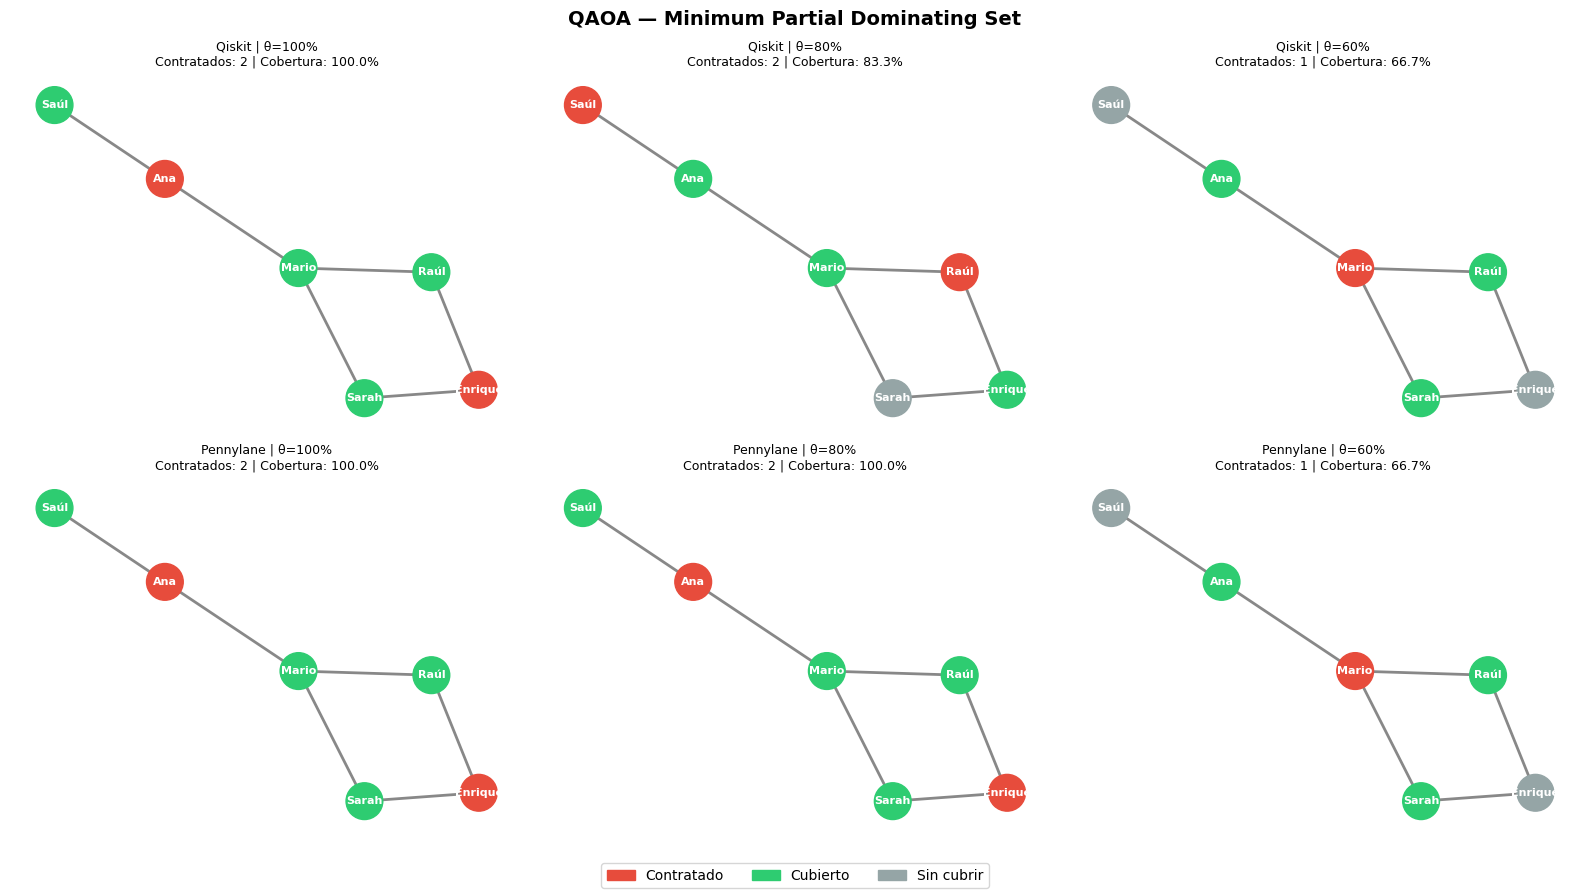

In [55]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
pos = nx.spring_layout(G, seed=42)

for row, provider in enumerate(PROVIDERS):
    for col, theta in enumerate(THETAS):
        res   = results[(provider, theta)]
        sol   = res['solution']
        hired = set(res['hired'])
        covered = set(hired)
        for h in hired:
            covered.update(G.neighbors(h))

        colors = []
        for node in G.nodes():
            if node in hired:
                colors.append('#e74c3c')
            elif node in covered:
                colors.append('#2ecc71')
            else:
                colors.append('#95a5a6')

        ax = axes[row][col]
        nx.draw_networkx(
            G, pos=pos, ax=ax,
            node_color=colors, node_size=700,
            font_size=8, font_color='white', font_weight='bold',
            edge_color='#888', width=2
        )
        ax.set_title(
            f'{provider.capitalize()} | θ={theta:.0%}\n'
            f'Contratados: {res["n_hired"]} | Cobertura: {res["coverage"]:.1%}',
            fontsize=9
        )
        ax.axis('off')

legend = [
    mpatches.Patch(color='#e74c3c', label='Contratado'),
    mpatches.Patch(color='#2ecc71', label='Cubierto'),
    mpatches.Patch(color='#95a5a6', label='Sin cubrir'),
]
fig.legend(handles=legend, loc='lower center', ncol=3, fontsize=10)
fig.suptitle('QAOA — Minimum Partial Dominating Set', fontsize=14, fontweight='bold')
plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.savefig('qaoa_solutions.png', dpi=150, bbox_inches='tight')
plt.show()

### 9.3 Tabla comparativa Qiskit vs PennyLane

In [56]:
import pandas as pd

rows = []
for provider in PROVIDERS:
    for theta in THETAS:
        r = results[(provider, theta)]
        rows.append({
            'Provider':       provider.capitalize(),
            'θ requerido':    f'{theta:.0%}',
            'Personas':       r['n_hired'],
            'Contratados':    ', '.join(r['hired']),
            'Cobertura':      f"{r['coverage']:.1%}",
            'γ óptimos':      [f'{v:.3f}' for v in r['optimal_gamma']],
            'β óptimos':      [f'{v:.3f}' for v in r['optimal_beta']],
            'Tiempo (s)':     f"{r['exec_time']:.1f}",
        })

df = pd.DataFrame(rows)
print(df.to_string(index=False))

 Provider θ requerido  Personas  Contratados Cobertura             γ óptimos             β óptimos Tiempo (s)
   Qiskit        100%         2 Enrique, Ana    100.0% [2.250, 2.168, 2.194] [0.293, 0.411, 0.176]        0.6
   Qiskit         80%         2   Raúl, Saúl     83.3% [2.680, 2.237, 2.068] [0.784, 0.322, 0.318]        0.6
   Qiskit         60%         1        Mario     66.7% [2.638, 2.363, 2.353] [0.382, 0.355, 0.414]        0.6
Pennylane        100%         2 Enrique, Ana    100.0% [1.168, 2.347, 1.401] [0.405, 0.319, 0.172]       13.2
Pennylane         80%         2 Enrique, Ana    100.0% [1.168, 2.347, 1.401] [0.405, 0.319, 0.172]       17.6
Pennylane         60%         1        Mario     66.7% [1.168, 2.347, 1.401] [0.405, 0.319, 0.172]       26.4


### 9.4 Gráficas comparativas

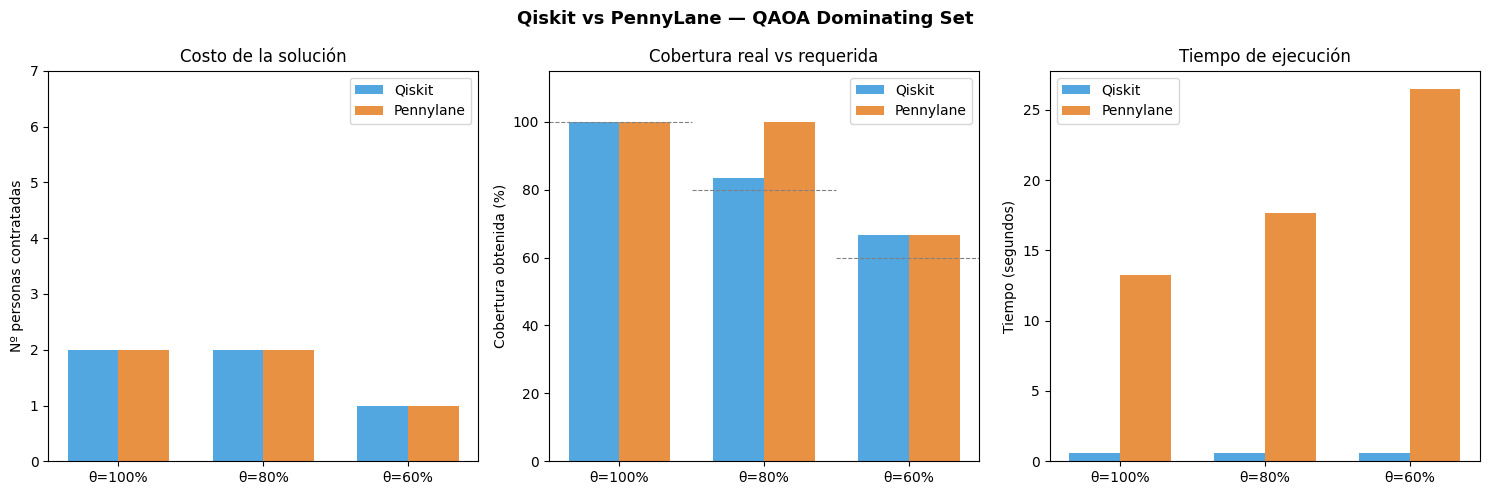

In [57]:
theta_labels = [f'{t:.0%}' for t in THETAS]
x = np.arange(len(THETAS))
width = 0.35

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

colors_provider = {'qiskit': '#3498db', 'pennylane': '#e67e22'}

# ── Número de personas contratadas ───────────────────────────────────
ax = axes[0]
for i, provider in enumerate(PROVIDERS):
    vals = [results[(provider, t)]['n_hired'] for t in THETAS]
    ax.bar(x + i * width - width/2, vals, width,
           label=provider.capitalize(), color=colors_provider[provider],
           alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels([f'θ={l}' for l in theta_labels])
ax.set_ylabel('Nº personas contratadas')
ax.set_title('Costo de la solución')
ax.legend()
ax.set_ylim(0, G.number_of_nodes() + 1)

# ── Cobertura obtenida ────────────────────────────────────────────────
ax = axes[1]
for i, provider in enumerate(PROVIDERS):
    vals = [results[(provider, t)]['coverage'] * 100 for t in THETAS]
    ax.bar(x + i * width - width/2, vals, width,
           label=provider.capitalize(), color=colors_provider[provider],
           alpha=0.85)
for j, t in enumerate(THETAS):
    ax.axhline(t * 100, color='gray', linestyle='--', linewidth=0.8,
               xmin=(j/len(THETAS)), xmax=((j+1)/len(THETAS)))
ax.set_xticks(x)
ax.set_xticklabels([f'θ={l}' for l in theta_labels])
ax.set_ylabel('Cobertura obtenida (%)')
ax.set_title('Cobertura real vs requerida')
ax.set_ylim(0, 115)
ax.legend()

# ── Tiempo de ejecución ───────────────────────────────────────────────
ax = axes[2]
for i, provider in enumerate(PROVIDERS):
    vals = [results[(provider, t)]['exec_time'] for t in THETAS]
    ax.bar(x + i * width - width/2, vals, width,
           label=provider.capitalize(), color=colors_provider[provider],
           alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels([f'θ={l}' for l in theta_labels])
ax.set_ylabel('Tiempo (segundos)')
ax.set_title('Tiempo de ejecución')
ax.legend()

fig.suptitle('Qiskit vs PennyLane — QAOA Dominating Set', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('qaoa_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

### 9.5 Histograma de mediciones (θ=100%)

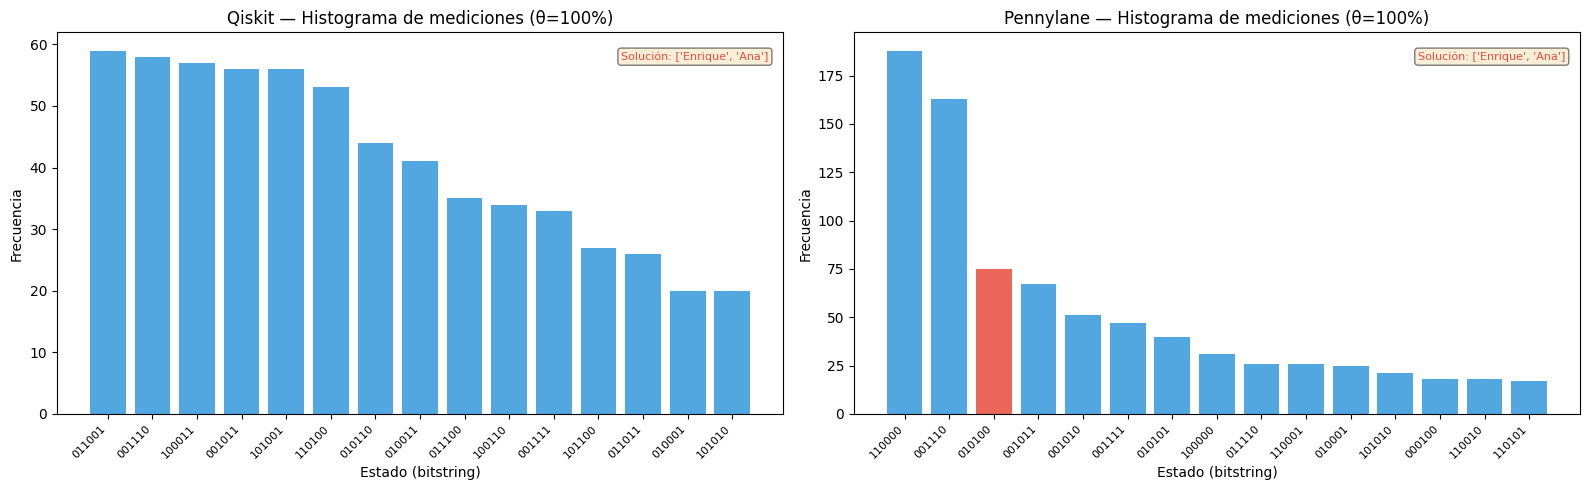

In [58]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, provider in zip(axes, PROVIDERS):
    counts = results[(provider, 1.0)]['counts']
    # Top 15 estados más frecuentes
    sorted_counts = sorted(counts.items(), key=lambda x: x[1], reverse=True)[:15]
    labels, freqs = zip(*sorted_counts)

    # Colorear la barra de la solución óptima
    optimal = ''.join(map(str, results[(provider, 1.0)]['solution']))
    bar_colors = ['#e74c3c' if l == optimal else '#3498db' for l in labels]

    ax.bar(range(len(labels)), freqs, color=bar_colors, alpha=0.85)
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=8)
    ax.set_xlabel('Estado (bitstring)')
    ax.set_ylabel('Frecuencia')
    ax.set_title(f'{provider.capitalize()} — Histograma de mediciones (θ=100%)')

    # Leyenda con la solución
    sol_names = results[(provider, 1.0)]['hired']
    ax.text(0.98, 0.95, f'Solución: {sol_names}',
            transform=ax.transAxes, ha='right', va='top',
            fontsize=8, color='#e74c3c',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig('qaoa_histograms.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Verificación: solución exacta por fuerza bruta

Para grafos pequeños podemos verificar que QAOA encuentra la solución óptima.

In [59]:
def brute_force_dominating_set(G: nx.Graph, theta: float,
                                A: float = 1.0, B: float = 3.0) -> dict:
    """
    Encuentra la solución óptima exacta por enumeración exhaustiva.
    Solo viable para grafos pequeños (n ≤ ~20).
    """
    nodes = list(G.nodes())
    n     = len(nodes)
    best_cost = np.inf
    best_sol  = None

    for bits in product([0, 1], repeat=n):
        bits = list(bits)
        cov  = coverage_fraction(bits, G)
        if cov >= theta:
            cost = sum(bits)  # minimizar contratados
            if cost < best_cost:
                best_cost = cost
                best_sol  = bits

    hired    = [nodes[i] for i, v in enumerate(best_sol) if v == 1]
    coverage = coverage_fraction(best_sol, G)
    return {'solution': best_sol, 'hired': hired,
            'n_hired': sum(best_sol), 'coverage': coverage}


print('\n── Soluciones óptimas (fuerza bruta) ──')
for theta in THETAS:
    opt = brute_force_dominating_set(G, theta)
    print(f'\nθ = {theta:.0%}')
    print(f'  Contratados ({opt["n_hired"]}): {opt["hired"]}')
    print(f'  Cobertura: {opt["coverage"]:.1%}')

print('\n── Comparación QAOA vs Óptimo ──')
print(f'{"θ":>6} {"Provider":>12} {"QAOA":>6} {"Óptimo":>8} {"Cobertura":>10}')
print('-' * 50)
for theta in THETAS:
    opt = brute_force_dominating_set(G, theta)
    for provider in PROVIDERS:
        r = results[(provider, theta)]
        match = '✅' if r['n_hired'] == opt['n_hired'] else '⚠️'
        print(f'{theta:>6.0%} {provider.capitalize():>12} '
              f'{r["n_hired"]:>6} {opt["n_hired"]:>8}  '
              f'{r["coverage"]:>8.1%}  {match}')


── Soluciones óptimas (fuerza bruta) ──

θ = 100%
  Contratados (2): ['Enrique', 'Ana']
  Cobertura: 100.0%

θ = 80%
  Contratados (2): ['Raúl', 'Saúl']
  Cobertura: 83.3%

θ = 60%
  Contratados (1): ['Mario']
  Cobertura: 66.7%

── Comparación QAOA vs Óptimo ──
     θ     Provider   QAOA   Óptimo  Cobertura
--------------------------------------------------
  100%       Qiskit      2        2    100.0%  ✅
  100%    Pennylane      2        2    100.0%  ✅
   80%       Qiskit      2        2     83.3%  ✅
   80%    Pennylane      2        2    100.0%  ✅
   60%       Qiskit      1        1     66.7%  ✅
   60%    Pennylane      1        1     66.7%  ✅


## 11. Uso genérico — cualquier grafo de entrada

El sistema acepta cualquier grafo NetworkX. Ejemplo con un grafo aleatorio.

=== Grafo del enunciado ===


Provider:    Qiskit
Contratados: ['Sarah', 'Ana'] (2 personas)
Cobertura:   83.3%  (requerida: 80%)
Tiempo:      1.1s


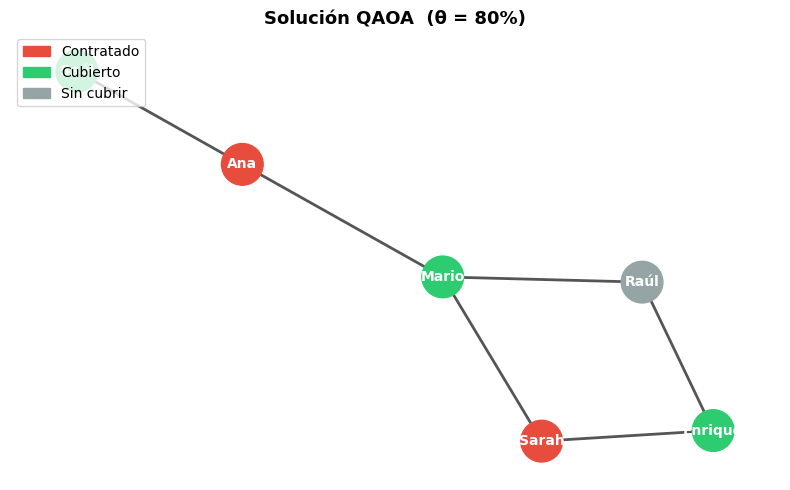


=== Grafo aleatorio (8 nodos) ===
Provider:    PennyLane
Contratados: ['P5'] (1 personas)
Cobertura:   75.0%  (requerida: 75%)
Tiempo:      73.1s


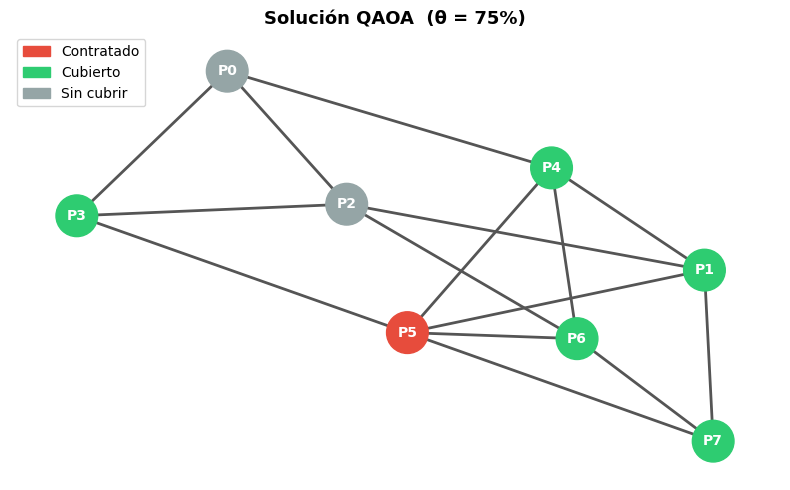

In [60]:
def run_qaoa(graph: nx.Graph,
             provider: str  = 'qiskit',
             theta: float   = 1.0,
             p: int         = 3,
             A: float       = 1.0,
             B: float       = 3.0,
             shots: int     = 1024,
             visualize: bool = True) -> dict:
    """
    Función de alto nivel para ejecutar QAOA sobre cualquier grafo.

    Parámetros
    ----------
    graph    : grafo NetworkX
    provider : 'qiskit' | 'pennylane'
    theta    : cobertura mínima requerida (0.0 – 1.0)
    p        : capas QAOA
    A, B     : pesos del Hamiltoniano
    shots    : número de mediciones
    visualize: mostrar grafo solución

    Retorna
    -------
    dict con la solución completa
    """
    config = {
        'graph': graph, 'provider': provider, 'theta': theta,
        'p': p, 'A': A, 'B': B, 'shots': shots
    }
    solver = QAOASolverFactory.create(config)
    result = solver.solve()

    print(f'Provider:    {result["provider"]}')
    print(f'Contratados: {result["hired"]} ({result["n_hired"]} personas)')
    print(f'Cobertura:   {result["coverage"]:.1%}  (requerida: {theta:.0%})')
    print(f'Tiempo:      {result["exec_time"]:.1f}s')

    if visualize:
        visualize_graph(graph, result['solution'], theta)

    return result


# ── Ejemplo con el grafo del enunciado ───────────────────────────────
print('=== Grafo del enunciado ===')
r = run_qaoa(G, provider='qiskit', theta=0.8)

# ── Ejemplo con grafo aleatorio ──────────────────────────────────────
print('\n=== Grafo aleatorio (8 nodos) ===')
G_random = nx.erdos_renyi_graph(8, 0.4, seed=42)
nx.set_node_attributes(G_random, {i: f'P{i}' for i in G_random.nodes()}, 'name')
G_random = nx.relabel_nodes(G_random, {i: f'P{i}' for i in G_random.nodes()})
r2 = run_qaoa(G_random, provider='pennylane', theta=0.75)